import pandas as pd
import seaborn as sns

print("Pandas version:", pd.__version__)

In [3]:
import os
import time
import shutil
import pathlib
import itertools
from PIL import Image

import cv2
import numpy as np
import pandas as pd
import seaborn as sns
sns.set_style('darkgrid')
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam, Adamax
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Activation, Dropout, BatchNormalization
from tensorflow.keras import regularizers

import warnings
warnings.filterwarnings("ignore")

print ('modules loaded')

modules loaded


In [4]:
import os

# check current working folder
print("Current path:", os.getcwd())

# dataset path
train_path = "../data/train"
valid_path = "../data/valid"

# check folders inside dataset
print("Train classes:", os.listdir(train_path))
print("Validation classes:", os.listdir(valid_path))

Current path: c:\Users\dell\Downloads\DTI\data
Train classes: ['Aphid', 'Black Rust', 'Blast', 'Brown Rust', 'Common Root Rot', 'Fusarium Head Blight', 'Healthy', 'Leaf Blight', 'Mildew', 'Mite', 'Septoria', 'Smut', 'Stem fly', 'Tan spot', 'Yellow Rust']
Validation classes: ['aphid_valid', 'black_rust_valid', 'blast_test_valid', 'brown_rust_valid', 'common_root_rot_valid', 'fusarium_head_blight_valid', 'healthy_valid', 'leaf_blight_valid', 'mildew_valid', 'mite_valid', 'septoria_valid', 'smut_valid', 'stem_fly_valid', 'tan_spot_valid', 'yellow_rust_valid']


In [5]:
import os

train_path = "C:/Users/dell/Downloads/DTI/data/train"
valid_path = "C:/Users/dell/Downloads/DTI/data/valid"

print(os.listdir(train_path))

['Aphid', 'Black Rust', 'Blast', 'Brown Rust', 'Common Root Rot', 'Fusarium Head Blight', 'Healthy', 'Leaf Blight', 'Mildew', 'Mite', 'Septoria', 'Smut', 'Stem fly', 'Tan spot', 'Yellow Rust']


In [6]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_dir = "../data/train"
valid_dir = "../data/valid"

train_datagen = ImageDataGenerator(rescale=1./255)
valid_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

valid_generator = valid_datagen.flow_from_directory(
    valid_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

Found 13564 images belonging to 15 classes.
Found 300 images belonging to 15 classes.


In [7]:
import pandas as pd
import os

filepaths = []
labels = []

data_dir = "../data/train"   # change if needed

for label in os.listdir(data_dir):
    folder = os.path.join(data_dir, label)
    
    for file in os.listdir(folder):
        filepaths.append(os.path.join(folder, file))
        labels.append(label)

data = pd.DataFrame({
    "filepath": filepaths,
    "label": labels
})

print(data.head())
print(data.shape)

                            filepath  label
0    ../data/train\Aphid\aphid_0.png  Aphid
1    ../data/train\Aphid\aphid_1.png  Aphid
2   ../data/train\Aphid\aphid_10.png  Aphid
3  ../data/train\Aphid\aphid_100.png  Aphid
4  ../data/train\Aphid\aphid_101.png  Aphid
(13105, 2)


In [8]:
from sklearn.model_selection import train_test_split

strat = data['label']

train_df, dummy_df = train_test_split(
    data,
    train_size=0.80,
    shuffle=True,
    random_state=123,
    stratify=strat
)

strat = dummy_df['label']

valid_df, test_df = train_test_split(
    dummy_df,
    train_size=0.5,
    shuffle=True,
    random_state=123,
    stratify=strat
)

In [9]:
print("Training set shape:", train_df.shape)
print("Validation set shape:", valid_df.shape)
print("Test set shape:", test_df.shape)

Training set shape: (10484, 2)
Validation set shape: (1310, 2)
Test set shape: (1311, 2)


In [10]:
print(train_df.columns)

Index(['filepath', 'label'], dtype='object')


In [11]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# define parameters
batch_size = 32
img_size = (150, 150)

# define generators
tr_gen = ImageDataGenerator(rescale=1./255)
ts_gen = ImageDataGenerator(rescale=1./255)
train_gen = tr_gen.flow_from_dataframe(
    train_df,
    x_col='filepath',
    y_col='label',
    target_size=img_size,
    class_mode='categorical',
    color_mode='rgb',
    shuffle=True,
    batch_size=batch_size
)

Found 10483 validated image filenames belonging to 15 classes.


In [12]:
train_gen = tr_gen.flow_from_dataframe(
    train_df,
    x_col='filepath',
    y_col='label',
    target_size=img_size,
    class_mode='categorical',
    color_mode='rgb',
    shuffle=True,
    batch_size=batch_size
)

valid_gen = ts_gen.flow_from_dataframe(
    valid_df,
    x_col='filepath',
    y_col='label',
    target_size=img_size,
    class_mode='categorical',
    color_mode='rgb',
    shuffle=False,
    batch_size=batch_size
)

test_gen = ts_gen.flow_from_dataframe(
    test_df,
    x_col='filepath',
    y_col='label',
    target_size=img_size,
    class_mode='categorical',
    color_mode='rgb',
    shuffle=False,
    batch_size=batch_size
)

Found 10483 validated image filenames belonging to 15 classes.
Found 1310 validated image filenames belonging to 15 classes.
Found 1311 validated image filenames belonging to 15 classes.


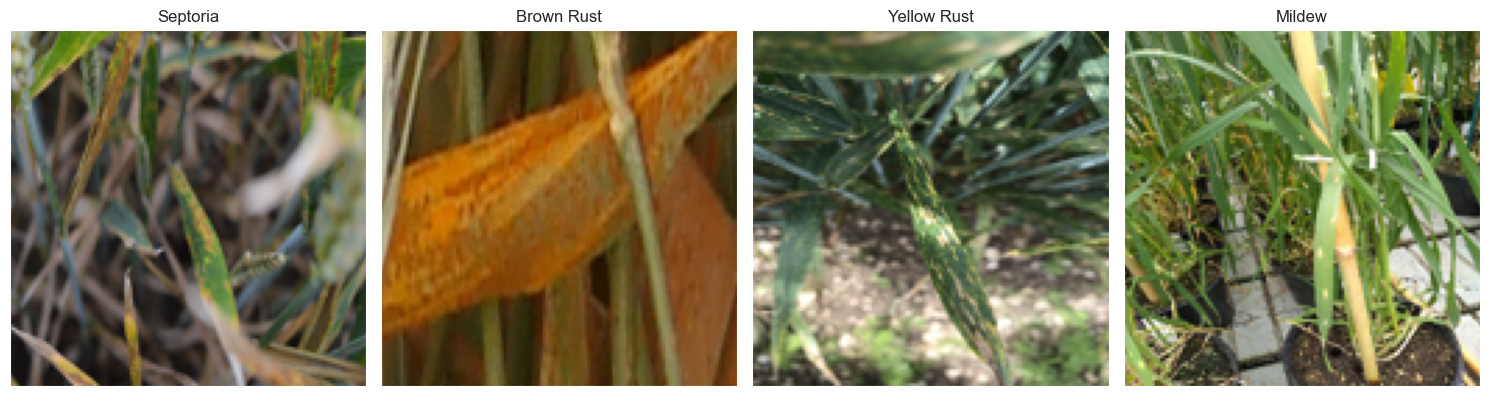

In [13]:
import matplotlib.pyplot as plt
from PIL import Image

class_samples = []

for label in test_df['label'].unique():
    sample = test_df[test_df['label'] == label].iloc[0]
    class_samples.append((sample['filepath'], sample['label']))

target_size = (128, 128)

fig, axes = plt.subplots(
    nrows=1,
    ncols=4,
    figsize=(15,5),
    subplot_kw={'xticks': [], 'yticks': []}
)

for ax, (filepath, label) in zip(axes, class_samples):
    img = Image.open(filepath)
    img_resized = img.resize(target_size)
    ax.imshow(img_resized)
    ax.set_title(label)

plt.tight_layout()
plt.savefig('Display_images.jpg', dpi=1200)
plt.show()

In [14]:
class myCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        if logs is None:
            logs = {}
        accuracy = logs.get('accuracy')
        val_accuracy = logs.get('val_accuracy')
        
        if accuracy:
            print(f"Epoch {epoch + 1}: Training accuracy is {accuracy:.4f}")
        if val_accuracy:
            print(f"Epoch {epoch + 1}: Validation accuracy is {val_accuracy:.4f}")
        
        if (accuracy and accuracy > 0.99) or (val_accuracy and val_accuracy > 0.99):
            print("\nReached 99% accuracy in training or validation, so cancelling training!")

In [15]:
model = Sequential()

model.add(tf.keras.layers.InputLayer(input_shape=(150, 150, 3)))

model.add(Conv2D(filters=64, kernel_size=(3, 3), strides=(1, 1), activation='relu'))
model.add(Conv2D(filters=64, kernel_size=(3, 3), strides=(1, 1), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))  
model.add(BatchNormalization())


model.add(Conv2D(filters=64, kernel_size=(3, 3), strides=(1, 1), activation='relu'))
model.add(Conv2D(filters=64, kernel_size=(3, 3), strides=(1, 1), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))  
model.add(BatchNormalization())


model.add(Conv2D(filters=64, kernel_size=(3, 3), strides=(1, 1), activation='relu'))
model.add(Conv2D(filters=64, kernel_size=(3, 3), strides=(1, 1), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))  
model.add(BatchNormalization())
model.add(Dropout(0.25))

model.add(Conv2D(filters=64, kernel_size=(3, 3), strides=(1, 1), activation='relu'))
model.add(Conv2D(filters=64, kernel_size=(3, 3), strides=(1, 1), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2))) 
model.add(BatchNormalization())
model.add(Dropout(0.25))

model.add(Conv2D(filters=64, kernel_size=(3, 3), strides=(1, 1), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))  
model.add(BatchNormalization())
model.add(Dropout(0.25))

model.add(Flatten())  

model.add(Dropout(0.3))  

model.add(Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.0001)))


model.add(Dense(15, activation='softmax', kernel_regularizer=tf.keras.regularizers.l2(0.0001)))  



model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 146, 146, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 73, 73, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 73, 73, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 71, 71, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 69, 69, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 34, 34, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 34, 34, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 30, 30, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 15, 15, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 15, 15, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 13, 13, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 11, 11, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 5, 5, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 1, 1, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 1, 1, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1, 1, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 308,751 (1.18 MB)

 Trainable params: 308,111 (1.18 MB)

 Non-trainable params: 640 (2.50 KB)

In [18]:
import time

start_time = time.time()

class myCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs={}):
        if(logs.get('val_accuracy') > 0.98):
            print("\nReached 98% accuracy so cancelling training!")
            self.model.stop_training = True

callbacks = myCallback()

model.compile(optimizer=Adamax(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

history = model.fit(
    train_gen,
    epochs=60,
    batch_size=32,
    verbose=1,
    validation_data=valid_gen,
    callbacks=[callbacks]
)

end_time = time.time()
training_time = end_time - start_time
print(f"\nTotal training time: {training_time:.2f} seconds")
print(f"Time per epoch: {training_time/50:.2f} seconds")

Epoch 1/60
328/328 ━━━━━━━━━━━━━━━━━━━━ 1164s 4s/step - accuracy: 0.3351 - loss: 2.1722 - val_accuracy: 0.2466 - val_loss: 2.4045
Epoch 2/60
328/328 ━━━━━━━━━━━━━━━━━━━━ 972s 3s/step - accuracy: 0.4039 - loss: 1.9403 - val_accuracy: 0.4359 - val_loss: 1.8438
Epoch 3/60
328/328 ━━━━━━━━━━━━━━━━━━━━ 899s 3s/step - accuracy: 0.4498 - loss: 1.7865 - val_accuracy: 0.4374 - val_loss: 1.8526
Epoch 4/60
328/328 ━━━━━━━━━━━━━━━━━━━━ 873s 3s/step - accuracy: 0.4739 - loss: 1.6951 - val_accuracy: 0.4947 - val_loss: 1.6016
Epoch 5/60
328/328 ━━━━━━━━━━━━━━━━━━━━ 944s 3s/step - accuracy: 0.5013 - loss: 1.5927 - val_accuracy: 0.4924 - val_loss: 1.5868
Epoch 6/60
328/328 ━━━━━━━━━━━━━━━━━━━━ 1675s 5s/step - accuracy: 0.5332 - loss: 1.5014 - val_accuracy: 0.5237 - val_loss: 1.5187
Epoch 7/60
328/328 ━━━━━━━━━━━━━━━━━━━━ 1958s 6s/step - accuracy: 0.5579 - loss: 1.4068 - val_accuracy: 0.5427 - val_loss: 1.4774
Epoch 8/60
328/328 ━━━━━━━━━━━━━━━━━━━━ 30508s 93s/step - accuracy: 0.5709 - loss: 1.3436 - va

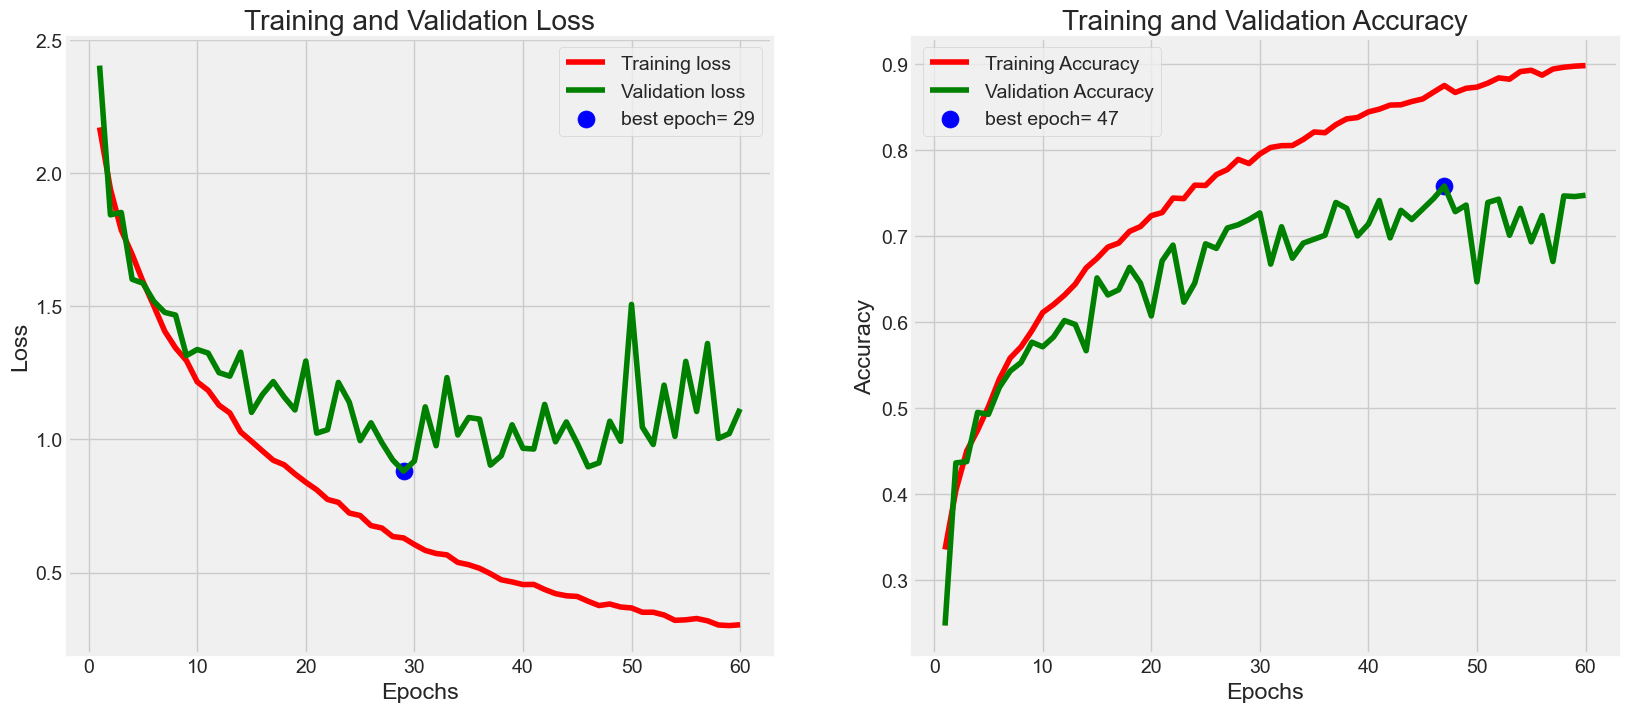

In [19]:
tr_acc = history.history['accuracy']
tr_loss = history.history['loss']
val_acc = history.history['val_accuracy']
val_loss = history.history['val_loss']
index_loss = np.argmin(val_loss)
val_lowest = val_loss[index_loss]
index_acc = np.argmax(val_acc)
acc_highest = val_acc[index_acc]
Epochs = [i+1 for i in range(len(tr_acc))]
loss_label = f'best epoch= {str(index_loss + 1)}'
acc_label = f'best epoch= {str(index_acc + 1)}'

plt.figure(figsize= (20, 8))
plt.style.use('fivethirtyeight')

plt.subplot(1, 2, 1)
plt.plot(Epochs, tr_loss, 'r', label= 'Training loss')
plt.plot(Epochs, val_loss, 'g', label= 'Validation loss')
plt.scatter(index_loss + 1, val_lowest, s= 150, c= 'blue', label= loss_label)
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(Epochs, tr_acc, 'r', label= 'Training Accuracy')
plt.plot(Epochs, val_acc, 'g', label= 'Validation Accuracy')
plt.scatter(index_acc + 1 , acc_highest, s= 150, c= 'blue', label= acc_label)
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout
plt.show()

In [ ]:
ts_length = len(test_df)
test_batch_size = max(sorted([ts_length // n for n in range(1, ts_length + 1) if ts_length%n == 0 and ts_length/n <= 80]))
test_steps = ts_length // test_batch_size

train_score = model.evaluate(train_gen, steps= test_steps, verbose= 1)
valid_score = model.evaluate(valid_gen, steps= test_steps, verbose= 1)
test_score = model.evaluate(test_gen, steps= test_steps, verbose= 1)

print("Train Loss: ", train_score[0])
print("Train Accuracy: ", train_score[1])
print('-' * 20)
print("Valid Loss: ", valid_score[0])
print("Valid Accuracy: ", valid_score[1])
print('-' * 20)
print("Test Loss: ", test_score[0])
print("Test Accuracy: ", test_score[1])

19/19 ━━━━━━━━━━━━━━━━━━━━ 11s 533ms/step - accuracy: 0.8602 - loss: 0.3956
19/19 ━━━━━━━━━━━━━━━━━━━━ 10s 500ms/step - accuracy: 0.6990 - loss: 1.1118
19/19 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.6776 - loss: 1.0965
Train Loss:  0.3956384062767029
Train Accuracy:  0.8601973652839661
--------------------
Valid Loss:  1.1118383407592773
Valid Accuracy:  0.6990131735801697
--------------------
Test Loss:  1.0964741706848145
Test Accuracy:  0.6776315569877625


In [4]:
preds = model.predict(test_gen)
y_pred = np.argmax(preds, axis=1)

NameError: name 'model' is not defined

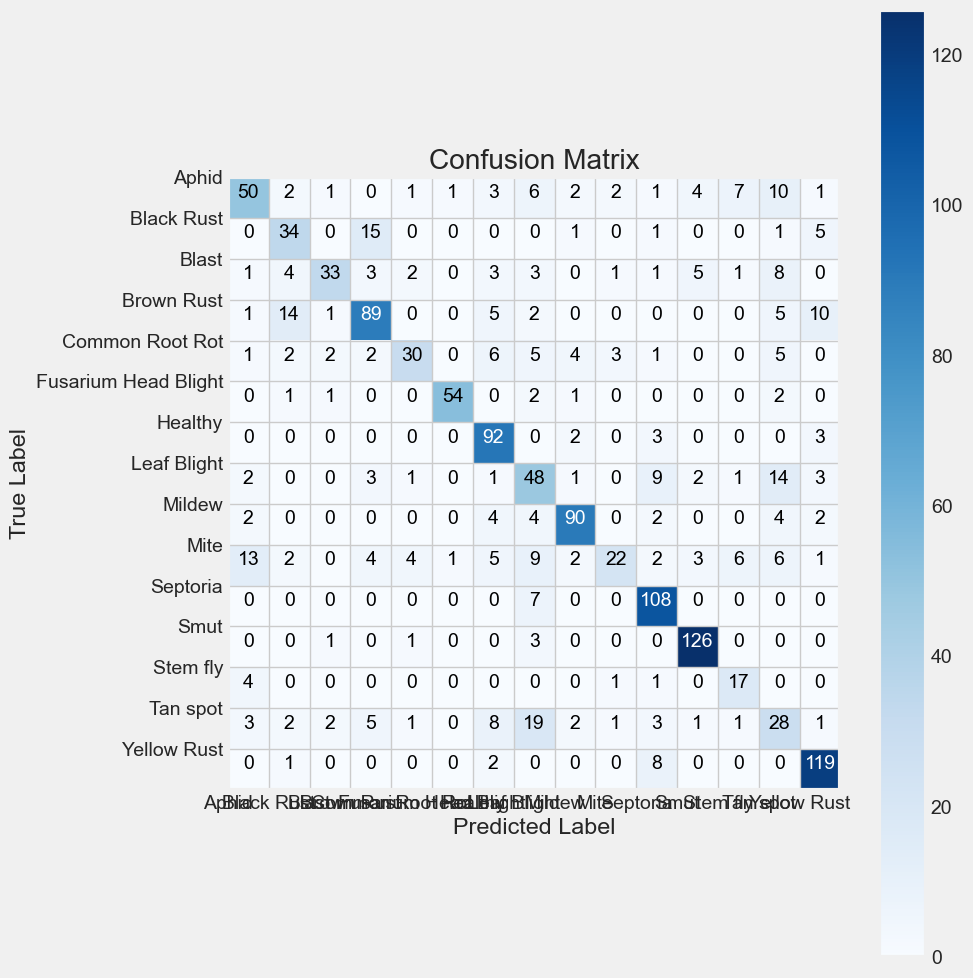

In [21]:
g_dict = test_gen.class_indices
classes = list(g_dict.keys())

cm = confusion_matrix(test_gen.classes, y_pred)

plt.figure(figsize= (10, 10))
plt.imshow(cm, interpolation= 'nearest', cmap= plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()

tick_marks = np.arange(len(classes))
plt.xticks(tick_marks - 0.5, classes)  
plt.yticks(tick_marks - 0.5, classes) 


thresh = cm.max() / 2.
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, cm[i, j], horizontalalignment= 'center', color= 'white' if cm[i, j] > thresh else 'black')

plt.tight_layout()
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

plt.show()

In [22]:
import json
class_names = list(train_gen.class_indices.keys())
with open('class_names.json', 'w') as f:
    json.dump(class_names, f)

In [23]:
model.save('wheat_disease_model.h5')

In [7]:
from tensorflow.keras.models import load_model
import os

# Correct path - model is inside the 'data' folder
model_path = '../data/wheat_disease_model.h5'

print(f"Checking model at: {model_path}")
print(f"Current directory: {os.getcwd()}")

if os.path.exists(model_path):
    model = load_model(model_path)
    print("✅ Model loaded successfully!")
    print(f"Model input shape: {model.input_shape}")
else:
    print("❌ Still not found!")
    print("Files in current directory:")
    print(os.listdir('.'))
    print("Files in data directory:")
    print(os.listdir('../data'))

Checking model at: ../data/wheat_disease_model.h5
Current directory: c:\Users\dell\Downloads\DTI\src


✅ Model loaded successfully!
Model input shape: (None, 150, 150, 3)


In [9]:
from tensorflow.keras.models import load_model
from PIL import Image
import numpy as np
import os

# Load the model
model = load_model('../data/wheat_disease_model.h5')
print("✅ Model loaded successfully!")

# Test with an uploaded image
from IPython.display import display
uploaded = None

# Simple file uploader for notebook (using widgets)
try:
    from ipywidgets import FileUpload
    uploader = FileUpload(accept='image/*', multiple=False)
    display(uploader)
    
    def on_upload_change(change):
        global uploaded
        if uploader.value:
            uploaded = uploader.value[0]['content']
            print("Image uploaded! Processing...")
            
            # Process the image
            image = Image.open(uploaded).resize((150, 150))
            img_array = np.array(image) / 255.0
            img_array = np.expand_dims(img_array, axis=0)

            preds = model.predict(img_array, verbose=0)[0]
            
            print("\n🔍 **Prediction Probabilities:**")
            for i, name in enumerate(class_names):
                print(f"{name:20s}: {preds[i]*100:6.2f}%")
            
            predicted = class_names[np.argmax(preds)]
            confidence = preds[np.argmax(preds)] * 100
            print(f"\nFinal Prediction: **{predicted}** with {confidence:.1f}% confidence")
    
    uploader.observe(on_upload_change, names='value')
    
except:
    print("Please run this in Jupyter notebook. If it doesn't work, use the manual path method below.")

✅ Model loaded successfully!
Please run this in Jupyter notebook. If it doesn't work, use the manual path method below.
